In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import spearmanr
import json


In [3]:
# ── Load distance matrices ───────────────────────────────────────────────
wd_filename  = 'Data/wasserstein_distances_full.npy'
swd_filename = 'Data/sliced_wasserstein_distances_full.npy'

WD_matrix  = np.load(wd_filename)
SWD_matrix = np.load(swd_filename)

# ── output ───────────────────────────────────────────────
ground_truth = np.load('Data/y_modulus.npy')
distance_full = WD_matrix # Choose between WD_matrix and SWD_matrix
distance_full_sliced = SWD_matrix # Choose between WD_matrix and SWD_matrix


In [4]:
def bump(d, r, beta, ampl):
    a = 1.0 - (d**2 / r**2)
    bump_values = np.zeros_like(a)
    
    # Only compute where a > 0
    positive_mask = a > 0.0
    if np.any(positive_mask):
        #beta = 0.1
        e = np.exp((-beta / a[positive_mask]) + beta)
        bump_values[positive_mask] = ampl * e
    
    return bump_values


def load_configurations(json_file_name):
    """Load the training configurations"""
    with open(json_file_name, 'r') as f:
        configs = json.load(f)
    return configs

pairs = 124750
SLE vs true W2:    rho = 0.9757
Sliced vs true W2: rho = 0.9918
SLE vs sliced:     rho = 0.9681


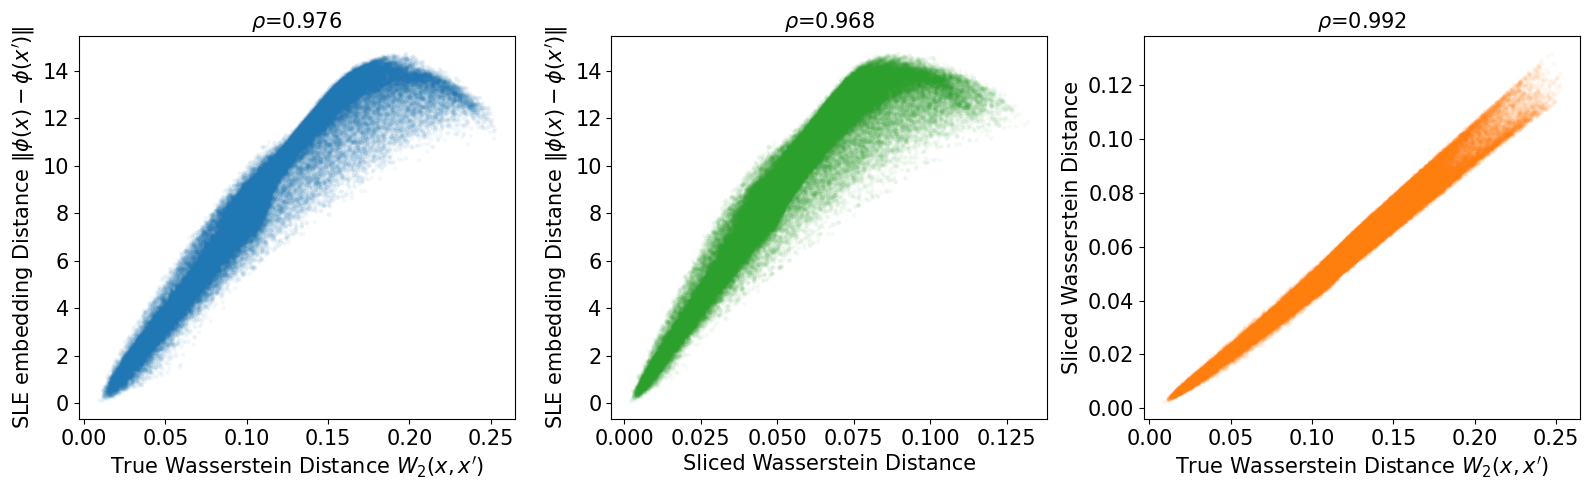

In [5]:
import numpy as np, matplotlib.pyplot as plt
from scipy.spatial.distance import pdist
from scipy.stats import spearmanr

r_bump, beta, a_bump = 0.18, 1.0, 1.0

N  = distance_full.shape[0]
iu = np.triu_indices(N, 1)

phi       = bump(distance_full, r_bump, beta=beta, ampl=a_bump)
true_w2   = distance_full[iu]
sliced_w2 = distance_full_sliced[iu]
embed_d   = pdist(phi)

rho_sle     = spearmanr(true_w2, embed_d).statistic
rho_swd     = spearmanr(true_w2, sliced_w2).statistic
rho_sle_swd = spearmanr(sliced_w2, embed_d).statistic

print(f"pairs = {true_w2.size}")
print(f"SLE vs true W2:    rho = {rho_sle:.4f}")
print(f"Sliced vs true W2: rho = {rho_swd:.4f}")
print(f"SLE vs sliced:     rho = {rho_sle_swd:.4f}")

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
pkw = dict(s=10, alpha=0.05, edgecolors='none')

axes[0].scatter(true_w2, embed_d, color='tab:blue', **pkw)
axes[0].set_xlabel(r"True Wasserstein Distance $W_2(x,x')$", fontsize=15)
axes[0].set_ylabel(r"SLE embedding Distance $\|\phi(x)-\phi(x')\|$", fontsize=15)
axes[0].set_title(rf"$\rho$={rho_sle:.3f}", fontsize=15)

axes[1].scatter(sliced_w2, embed_d, color='tab:green', **pkw)
axes[1].set_xlabel("Sliced Wasserstein Distance", fontsize=15)
axes[1].set_ylabel(r"SLE embedding Distance $\|\phi(x)-\phi(x')\|$", fontsize=15)
axes[1].set_title(rf"$\rho$={rho_sle_swd:.3f}", fontsize=15)


axes[2].scatter(true_w2, sliced_w2, color='tab:orange', **pkw)
axes[2].set_xlabel(r"True Wasserstein Distance $W_2(x,x')$", fontsize=15)
axes[2].set_ylabel("Sliced Wasserstein Distance", fontsize=15)
axes[2].set_title(rf"$\rho$={rho_swd:.3f}", fontsize=15)


for ax in axes:
    ax.tick_params(axis='both', which='major', labelsize=15)

plt.tight_layout()
# plt.savefig('appendix14_distortion_analysis_3panel.png', dpi=300)
plt.show()

pairs = 124750
SLE vs true W2:    rho = 0.9444
Sliced vs true W2: rho = 0.9918
SLE vs sliced:     rho = 0.9299


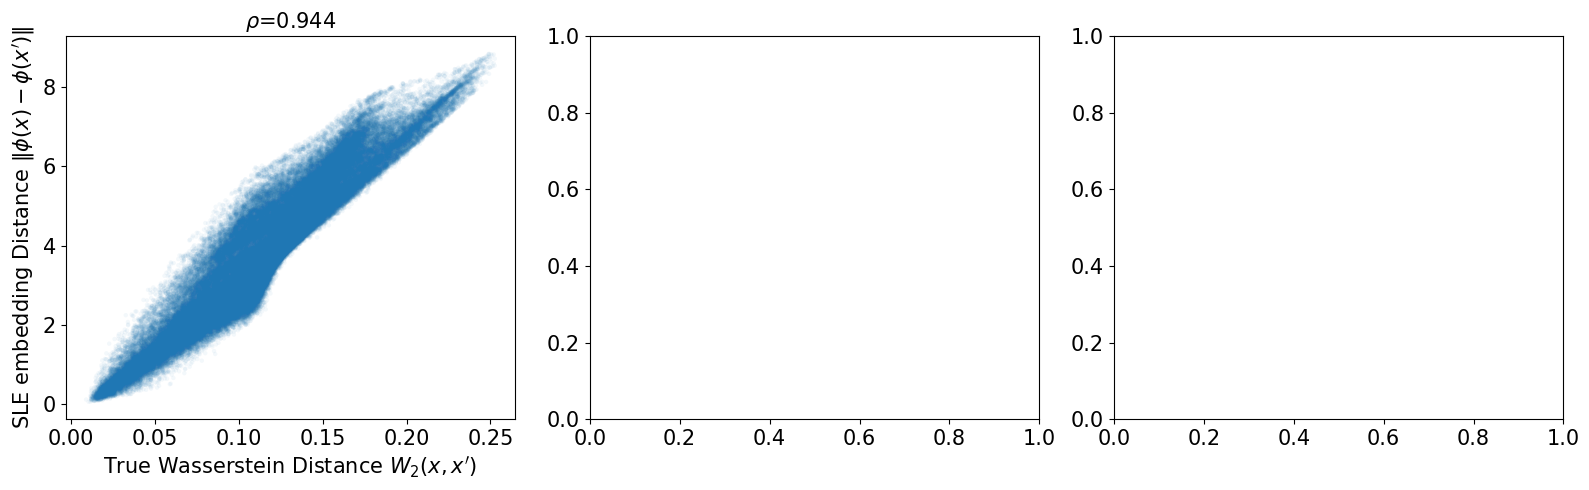

In [ ]:
import numpy as np, matplotlib.pyplot as plt
from scipy.spatial.distance import pdist
from scipy.stats import spearmanr

r_bump, beta, a_bump = 0.3, 1.0, 1.0

N  = distance_full.shape[0]
iu = np.triu_indices(N, 1)

phi       = bump(distance_full, r_bump, beta=beta, ampl=a_bump)
true_w2   = distance_full[iu]
sliced_w2 = distance_full_sliced[iu]
embed_d   = pdist(phi)

rho_sle     = spearmanr(true_w2, embed_d).statistic
rho_swd     = spearmanr(true_w2, sliced_w2).statistic
rho_sle_swd = spearmanr(sliced_w2, embed_d).statistic

print(f"pairs = {true_w2.size}")
print(f"SLE vs true W2:    rho = {rho_sle:.4f}")
print(f"Sliced vs true W2: rho = {rho_swd:.4f}")
print(f"SLE vs sliced:     rho = {rho_sle_swd:.4f}")

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
pkw = dict(s=10, alpha=0.05, edgecolors='none')

axes[0].scatter(true_w2, embed_d, color='tab:blue', **pkw)
axes[0].set_xlabel(r"True Wasserstein Distance $W_2(x,x')$", fontsize=15)
axes[0].set_ylabel(r"SLE embedding Distance $\|\phi(x)-\phi(x')\|$", fontsize=15)
axes[0].set_title(rf"$\rho$={rho_sle:.3f}", fontsize=15)

# axes[1].scatter(sliced_w2, embed_d, color='tab:green', **pkw)
# axes[1].set_xlabel("Sliced Wasserstein Distance", fontsize=15)
# axes[1].set_ylabel(r"SLE embedding Distance $\|\phi(x)-\phi(x')\|$", fontsize=15)
# axes[1].set_title(rf"$\rho$={rho_sle_swd:.3f}", fontsize=15)


# axes[2].scatter(true_w2, sliced_w2, color='tab:orange', **pkw)
# axes[2].set_xlabel(r"True Wasserstein Distance $W_2(x,x')$", fontsize=15)
# axes[2].set_ylabel("Sliced Wasserstein Distance", fontsize=15)
# axes[2].set_title(rf"$\rho$={rho_swd:.3f}", fontsize=15)


for ax in axes:
    ax.tick_params(axis='both', which='major', labelsize=15)

plt.tight_layout()
plt.show()

# Running for multiple r values

In [18]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from scipy.stats import spearmanr

D  = np.asarray(distance_full, dtype=float)
N  = D.shape[0]
assert np.array_equal(D, D.T) and not np.diag(D).any()

iu      = np.triu_indices(N, 1)
true_w2 = D[iu]
d_max = true_w2.max()

def bump(d, r, beta, ampl):
    a = 1.0 - (d**2 / r**2)
    bump_values = np.zeros_like(a)
    
    # Only compute where a > 0
    positive_mask = a > 0.0
    if np.any(positive_mask):
        #beta = 0.1
        e = np.exp((-beta / a[positive_mask]) + beta)
        bump_values[positive_mask] = ampl * e
    
    return bump_values


beta   = 1.0
ampl = 1
r_grid = np.logspace(np.log10(np.percentile(true_w2, 1)), np.log10(0.3),60)
                    #  np.log10(2 * d_max), 60)

# r_grid = np.linspace(d_min, d_max, 60)

rows = []
for r in r_grid:
    Phi = bump(D, r, beta, ampl)
    A   = D < r

    G   = Phi @ Phi.T
    g   = np.diag(G)
    sq  = np.maximum(g[:, None] + g[None, :] - 2 * G, 0.0)
    ed  = np.sqrt(sq[iu])

    shared = (A @ A.T)[iu] > 0
    rho    = spearmanr(true_w2, ed).statistic if ed.std() > 0 else np.nan
    rho_r  = (spearmanr(true_w2[shared], ed[shared]).statistic
              if shared.sum() > 100 and ed[shared].std() > 0 else np.nan)

    rows.append(dict(r=r, rho=rho, rho_reach=rho_r,
                     reach=shared.mean(), sparsity=A.mean()))

df = pd.DataFrame(rows)
print(df.to_string(index=False, float_format=lambda v: f"{v:.4f}"))

dense   = df.r >= d_max
plateau = df.loc[dense, 'rho'].mean()
print(f"\nplateau rho (r >= d_max) = {plateau:.4f}  "
      f"(spread {df.loc[dense,'rho'].std():.2e}, {dense.sum()} pts)")

df

     r     rho  rho_reach  reach  sparsity
0.0224 -0.0696     0.5421 0.0255    0.0120
0.0234 -0.0896     0.5310 0.0312    0.0138
0.0244 -0.1096     0.5106 0.0380    0.0160
0.0255 -0.1288     0.5106 0.0456    0.0187
0.0267 -0.1465     0.5127 0.0533    0.0214
0.0279 -0.1622     0.5234 0.0610    0.0241
0.0291 -0.1754     0.5323 0.0697    0.0273
0.0305 -0.1862     0.5385 0.0787    0.0306
0.0318 -0.1949     0.5350 0.0893    0.0342
0.0333 -0.2013     0.5248 0.1003    0.0382
0.0348 -0.2052     0.5323 0.1131    0.0426
0.0363 -0.2066     0.5379 0.1255    0.0470
0.0379 -0.2058     0.5281 0.1411    0.0524
0.0397 -0.2029     0.5416 0.1551    0.0578
0.0414 -0.1980     0.5511 0.1691    0.0635
0.0433 -0.1910     0.5535 0.1869    0.0696
0.0452 -0.1817     0.5509 0.2072    0.0760
0.0473 -0.1703     0.5613 0.2278    0.0831
0.0494 -0.1570     0.5600 0.2508    0.0911
0.0516 -0.1418     0.5694 0.2748    0.0991
0.0540 -0.1245     0.5706 0.3033    0.1084
0.0564 -0.1047     0.5699 0.3322    0.1180
0.0589 -0.0

,r,rho,rho_reach,reach,sparsity
0,0.022383,-0.069578,0.542121,0.025539,0.011984
1,0.023390,-0.089620,0.530954,0.031206,0.013792
2,0.024442,-0.109601,0.510561,0.038020,0.016032
3,0.025541,-0.128816,0.510567,0.045587,0.018744
4,0.026690,-0.146528,0.512714,0.053299,0.021384
5,0.027890,-0.162178,0.523432,0.060994,0.024088
6,0.029144,-0.175382,0.532281,0.069723,0.027264
7,0.030455,-0.186247,0.538527,0.078709,0.030552
8,0.031825,-0.194948,0.534965,0.089251,0.034200
9,0.033256,-0.201308,0.524830,0.100265,0.038160


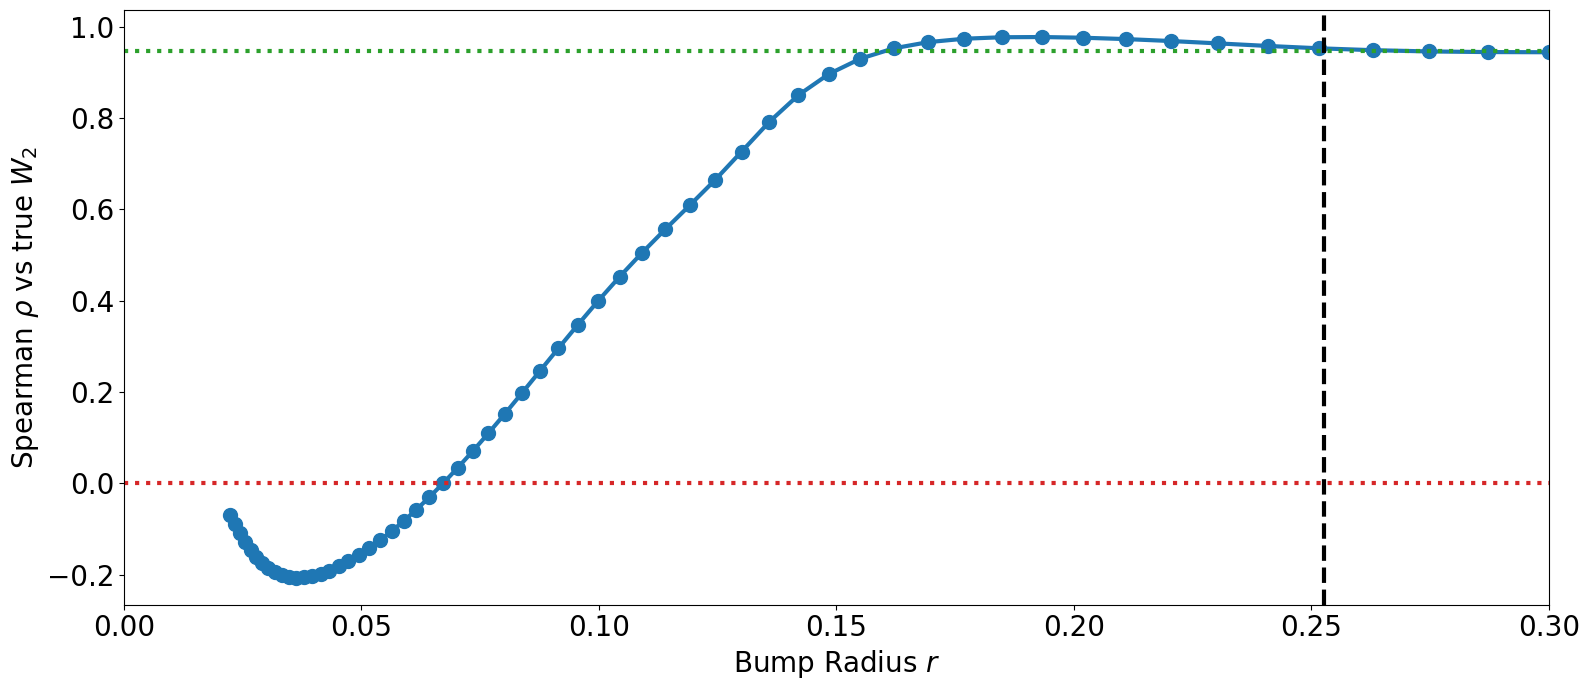

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(16, 7))

ax.plot(df.r, df.rho, 'o-', ms=10,lw=3)# , label='all pairs')
# ax.plot(df.r, df.rho_reach, 's--', ms=3, lw=2, alpha=.7, label='reachable pairs')
ax.axvline(d_max, c='k', ls='--', lw=3)# , label=r'$\max d$')
# ax.axvline(0.5049, c='k', ls='--', lw=3)# , label=r'$\max d$')
ax.axhline(plateau, c='C2', ls=':', lw=3)
ax.axhline(y=0, c='C3', ls=':', lw=3)
ax.set_xlabel('Bump Radius $r$', fontsize=20)
ax.set_ylabel(r'Spearman $\rho$ vs true $W_2$', fontsize=20)
ax.tick_params(axis='both', which='major', labelsize=20)
# ax.legend(fontsize=20, loc='lower right')
ax.set_xticks([0, 0.05,0.1, 0.15,0.2,0.25,0.3]) #,0.35,0.4,0.45,0.5])
ax.set_xlim([0,0.3]) # 0.52])

plt.tight_layout()
plt.show()